* This notebook applies an ETS(A,N,N) exponential smoothing model to the NASDAQ (^IXIC) daily closing index.

* The model emphasizes recent observations and is used to generate short-horizon forecasts.

In [9]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [11]:
df = pd.read_csv("../data/ixic.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)
y = df["^IXIC"].astype(float).sort_index()
y.name = "ixic_close"

print("Start:", y.index.min().date(), "End:", y.index.max().date())
print("Observations:", len(y))

Start: 2016-01-04 End: 2026-02-20
Observations: 2548


In [13]:
y_ets = y.reset_index(drop=True)

In [15]:
candidates = []

# ETS(A,N,N)
fit_ann = ExponentialSmoothing(
    y_ets,
    trend=None,
    seasonal=None,
    initialization_method="estimated"
).fit(optimized=True)

candidates.append(("ETS(A,N,N)", fit_ann.aic, fit_ann))

# ETS(A,A,N)
fit_aan = ExponentialSmoothing(
    y_ets,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit(optimized=True)

candidates.append(("ETS(A,A,N)", fit_aan.aic, fit_aan))

# ETS(A,A,A) with trading week seasonality
try:
    fit_aaa = ExponentialSmoothing(
        y_ets,
        trend="add",
        seasonal="add",
        seasonal_periods=5,
        initialization_method="estimated"
    ).fit(optimized=True)

    candidates.append(("ETS(A,A,A) (s=5)", fit_aaa.aic, fit_aaa))
except:
    print("Seasonal ETS failed (normal if weak seasonality)")

In [17]:
ets_table = (
    pd.DataFrame([(m, aic) for (m, aic, _) in candidates],
                 columns=["Model", "AIC"])
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("\nETS model comparison:")
display(ets_table)
best_name = ets_table.loc[0, "Model"]
best_fit = [f for (m, _, f) in candidates if m == best_name][0]

print("\nBest ETS model:", best_name)


ETS model comparison:


,Model,AIC
0,"ETS(A,N,N)",26118.580772
1,"ETS(A,A,N)",26151.273355
2,"ETS(A,A,A) (s=5)",26199.654469



Best ETS model: ETS(A,N,N)


In [19]:
H = 5

fc_vals = best_fit.forecast(H)
last_date = y.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=H+1)[1:]
fc_ets = pd.Series(fc_vals.values, index=future_dates, name="ETS_forecast")

print("\nETS 5-day forecast:")
print(fc_ets)


ETS 5-day forecast:
2026-02-23    22871.32598
2026-02-24    22871.32598
2026-02-25    22871.32598
2026-02-26    22871.32598
2026-02-27    22871.32598
Freq: B, Name: ETS_forecast, dtype: float64


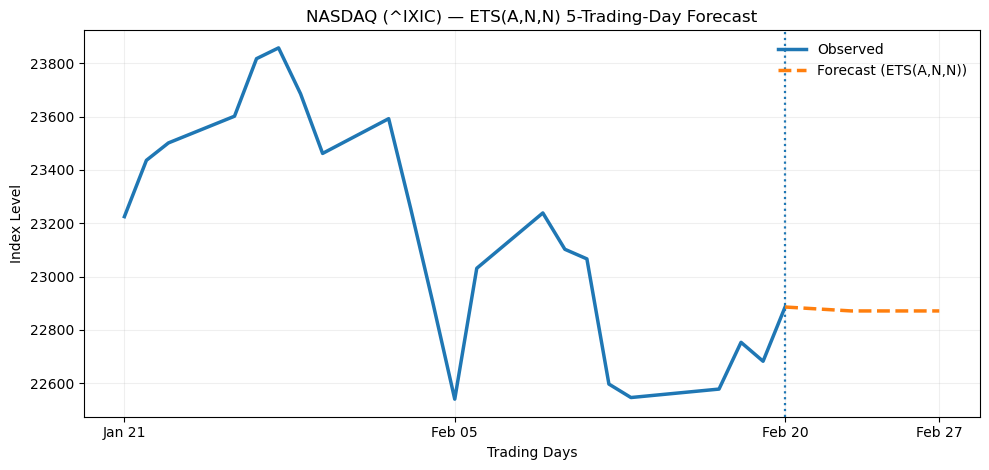

In [23]:
window = 22
hist = y.iloc[-window:]
last_date = hist.index[-1]

x_fc = pd.DatetimeIndex([last_date]).append(fc_ets.index)
y_fc = np.r_[hist.iloc[-1], fc_ets.values]

plt.figure(figsize=(10,4.8))
plt.plot(hist.index, hist.values, linewidth=2.5, label="Observed")
plt.axvline(last_date, linestyle=":", linewidth=1.6)
plt.plot(x_fc, y_fc, linestyle="--", linewidth=2.5,
         label=f"Forecast ({best_name})")

plt.title(f"NASDAQ (^IXIC) — {best_name} 5-Trading-Day Forecast")
plt.xlabel("Trading Days")
plt.ylabel("Index Level")
tick_dates = pd.to_datetime(sorted(set([
    hist.index[0],            # left edge
    hist.index[len(hist)//2], # middle
    last_date,                # Feb 20 (last observed)
    fc_ets.index[-1]          # Feb 27 (last forecast)
])))

ax = plt.gca()
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=0)

plt.grid(True, alpha=0.2)
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

In [42]:
ets_table = pd.DataFrame({
    "Date": fc_ets.index.strftime("%Y-%m-%d"),
    "ETS_Forecast": fc_ets.values.round(2)
})

ets_table

,Date,ETS_Forecast
0,2026-02-23,22871.33
1,2026-02-24,22871.33
2,2026-02-25,22871.33
3,2026-02-26,22871.33
4,2026-02-27,22871.33


* AIC selects ETS(A,N,N), meaning the model includes only a level component (no trend, no seasonality).
* The 5-day forecast is almost flat and stays near the last observed NASDAQ value.
This suggests recent fluctuations are treated as short-term noise, not a persistent trend.
* Compared to ARIMA, ETS provides a more conservative stabilization forecast.